Valuation date used: 2026-01-30
Tree horizon T: 10.00 years
Step size dt: 0.50
Number of steps: 20
Ho-Lee sigma: 0.010000
BDT sigma: 0.200000

Market curve on semiannual grid:
      date    t  zero_rate_cc      P0t
2026-01-30  0.5      0.036040 0.982142
2026-01-30  1.0      0.034917 0.965686
2026-01-30  1.5      0.034730 0.949239
2026-01-30  2.0      0.034926 0.932532
2026-01-30  2.5      0.035263 0.915617
2026-01-30  3.0      0.035650 0.898571
2026-01-30  3.5      0.036053 0.881451
2026-01-30  4.0      0.036459 0.864300
2026-01-30  4.5      0.036865 0.847137
2026-01-30  5.0      0.037273 0.829972
2026-01-30  5.5      0.037682 0.812814
2026-01-30  6.0      0.038094 0.795674
2026-01-30  6.5      0.038508 0.778566
2026-01-30  7.0      0.038922 0.761508
2026-01-30  7.5      0.039335 0.744520
2026-01-30  8.0      0.039746 0.727625
2026-01-30  8.5      0.040153 0.710845
2026-01-30  9.0      0.040554 0.694206
2026-01-30  9.5      0.040948 0.677731
2026-01-30 10.0      0.041333 0.661444

Cali

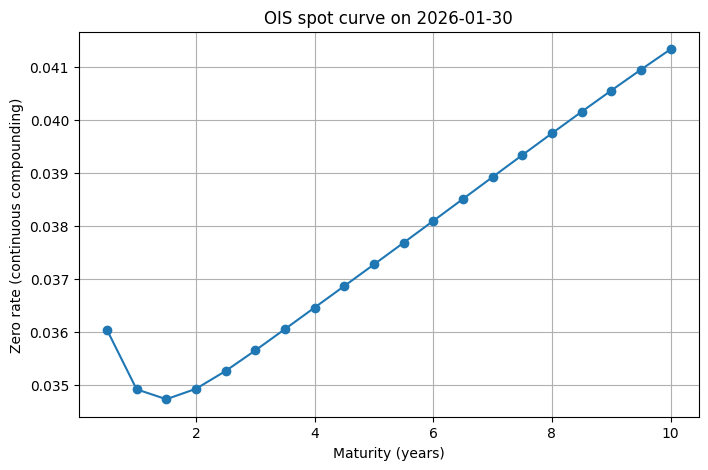

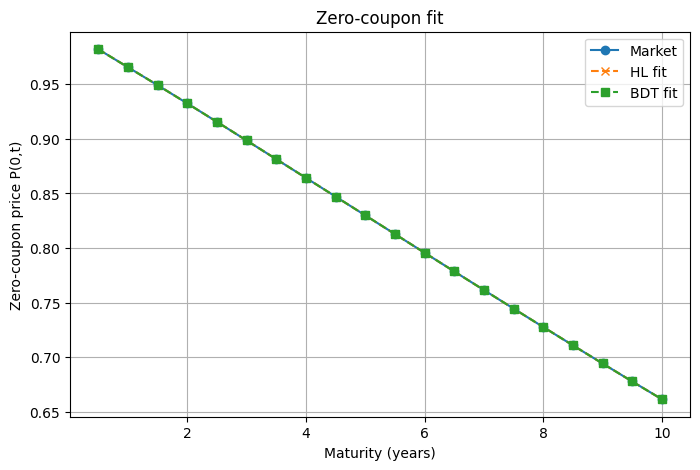


Ho-Lee tree (pivoted):
node        0         1         2         3         4         5         6   \
step                                                                         
1     0.036040                                                               
2     0.026735  0.040877                                                     
3     0.020264  0.034406  0.048548                                           
4     0.014414  0.028556  0.042698  0.056841                                 
5     0.008525  0.022667  0.036809  0.050951  0.065093                       
6     0.002544  0.016686  0.030828   0.04497  0.059113  0.073255             
7    -0.003505  0.010637  0.024779  0.038921  0.053064  0.067206  0.081348   
8    -0.009586  0.004556  0.018698  0.032841  0.046983  0.061125  0.075267   
9    -0.015654 -0.001512   0.01263  0.026772  0.040914  0.055056  0.069198   
10   -0.021687 -0.007545  0.006598   0.02074  0.034882  0.049024  0.063166   
11   -0.027681 -0.013539  0.000603  0.01

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

PARQUET_FILE = "ois_spot_curve_jan_2026_long.parquet"

VALUATION_DATE = "2026-01-30"

# Tree settings
dt = 0.5           # semiannual step
T = 10.0            # horizon in years; change as needed

# Volatility assumptions (replace with your estimated values later)
sigma_hl = 0.01    # Ho-Lee absolute short-rate vol (e.g. 1% p.a. in decimal units)
sigma_bdt = 0.20   # BDT log short-rate vol (e.g. 20% p.a.)

long = pd.read_parquet(PARQUET_FILE).copy()

# Keep only valid rows
long = long.dropna(subset=["date", "t", "zero_rate_cc"]).copy()
long = long.sort_values(["date", "t"])

valuation_date = pd.Timestamp(VALUATION_DATE)

curve_day = (
    long.loc[long["date"] == valuation_date, ["t", "zero_rate_cc"]]
    .dropna()
    .sort_values("t")
    .copy()
)

curve_day = curve_day[curve_day["t"] > 0].copy()
if curve_day.empty:
    raise ValueError(f"No curve data found for valuation date {valuation_date.date()}.")

curve_day["P0t"] = np.exp(-curve_day["zero_rate_cc"] * curve_day["t"])

# =========================
# INTERPOLATE TO SEMIANNUAL GRID
# =========================
grid = np.arange(dt, T + 1e-12, dt)

if curve_day["t"].max() < T:
    raise ValueError(
        f"Requested T={T:.2f}y but the available curve only goes to {curve_day['t'].max():.2f}y."
    )

t_obs = curve_day["t"].to_numpy()
P_obs = curve_day["P0t"].to_numpy()

# Interpolate log discount factors for numerical stability
logP_obs = np.log(P_obs)
logP_grid = np.interp(grid, t_obs, logP_obs)
P_market = np.exp(logP_grid)
z_grid = -np.log(P_market) / grid

market_curve = pd.DataFrame({
    "date": valuation_date,
    "t": grid,
    "zero_rate_cc": z_grid,
    "P0t": P_market
})

# Sanity checks
if not np.all(np.diff(market_curve["t"]) > 0):
    raise ValueError("Maturity grid is not strictly increasing.")
if not np.all((market_curve["P0t"] > 0) & (market_curve["P0t"] <= 1)):
    raise ValueError("Discount factors must be in (0, 1].")
if not np.all(np.diff(market_curve["P0t"]) <= 1e-10):
    print("Warning: Discount factors are not strictly decreasing everywhere. Check the source curve/interpolation.")

# =========================
# TREE / PRICING FUNCTIONS
# =========================
def next_state_prices(pi, r, dt):
    """
    Propagate Arrow-Debreu state prices one step forward
    under q=0.5, using continuously compounded short rates.
    """
    n = len(pi) - 1
    pi_next = np.zeros(n + 2)
    disc = np.exp(-np.asarray(r) * dt)
    for j in range(n + 1):
        contrib = 0.5 * pi[j] * disc[j]
        pi_next[j] += contrib
        pi_next[j + 1] += contrib
    return pi_next

def price_zeros_from_tree(tree, dt):
    """
    Reprice zero-coupon bonds from a calibrated short-rate tree.
    Returns model zero prices P(0, dt), P(0, 2dt), ..., P(0, N dt).
    """
    pi = np.array([1.0])
    prices = []
    for r in tree:
        pi = next_state_prices(pi, np.asarray(r), dt)
        prices.append(pi.sum())
    return np.array(prices)

def find_bracket(f, lo=-1.0, hi=1.0, step=1.0, max_expand=100):
    """
    Expand [lo, hi] until f(lo) and f(hi) have opposite signs.
    """
    flo = f(lo)
    fhi = f(hi)
    k = 0
    while flo * fhi > 0 and k < max_expand:
        lo -= step
        hi += step
        flo = f(lo)
        fhi = f(hi)
        k += 1
    if flo * fhi > 0:
        raise RuntimeError("Could not bracket the root.")
    return lo, hi

def calibrate_hl(P_market, sigma, dt=0.5):
    """
    Ho-Lee short-rate tree:
        r_{n,j} = a_n + (2j - n) * sigma * sqrt(dt)
    Sequentially calibrates a_n to match P_market.
    """
    N = len(P_market)
    pi = np.array([1.0])
    tree = []
    levels = []

    step = sigma * np.sqrt(dt)

    for n in range(N):
        j = np.arange(n + 1)

        def objective(a_n):
            r = a_n + (2 * j - n) * step
            return np.sum(pi * np.exp(-r * dt)) - P_market[n]

        lo, hi = find_bracket(objective, lo=-0.5, hi=0.5, step=0.5)
        sol = root_scalar(objective, bracket=[lo, hi], method="brentq")
        a_n = sol.root

        r_n = a_n + (2 * j - n) * step
        tree.append(r_n)
        levels.append(a_n)

        pi = next_state_prices(pi, r_n, dt)

    return tree, np.array(levels)

def calibrate_bdt(P_market, sigma, dt=0.5):
    """
    Black-Derman-Toy short-rate tree with constant log-vol:
        r_{n,j} = U_n * exp((2j - n) * sigma * sqrt(dt))
               = exp(logU_n + (2j - n) * sigma * sqrt(dt))
    Sequentially calibrates U_n to match P_market.
    """
    N = len(P_market)
    pi = np.array([1.0])
    tree = []
    log_levels = []

    step = sigma * np.sqrt(dt)

    for n in range(N):
        j = np.arange(n + 1)

        def objective(logU_n):
            r = np.exp(logU_n + (2 * j - n) * step)
            return np.sum(pi * np.exp(-r * dt)) - P_market[n]

        # Wide bracket in log-rate space
        sol = root_scalar(objective, bracket=[-15.0, 5.0], method="brentq")
        logU_n = sol.root

        r_n = np.exp(logU_n + (2 * j - n) * step)
        tree.append(r_n)
        log_levels.append(logU_n)

        pi = next_state_prices(pi, r_n, dt)

    return tree, np.array(log_levels)

def tree_to_dataframe(tree, dt):
    """
    Convert list of arrays [r_0, r_1, ..., r_{N-1}] into a tidy dataframe.
    """
    rows = []
    for n, r_n in enumerate(tree):
        time = (n + 1) * dt
        for j, r in enumerate(r_n):
            rows.append({"time": time, "step": n + 1, "node": j, "short_rate_cc": float(r)})
    return pd.DataFrame(rows)

# =========================
# CALIBRATE HL TREE
# =========================
hl_tree, hl_levels = calibrate_hl(P_market, sigma=sigma_hl, dt=dt)
P_hl = price_zeros_from_tree(hl_tree, dt)
hl_error = np.max(np.abs(P_hl - P_market))

# =========================
# CALIBRATE BDT TREE
# =========================
bdt_tree, bdt_log_levels = calibrate_bdt(P_market, sigma=sigma_bdt, dt=dt)
P_bdt = price_zeros_from_tree(bdt_tree, dt)
bdt_error = np.max(np.abs(P_bdt - P_market))

# =========================
# BUILD OUTPUT TABLES
# =========================
hl_tree_df = tree_to_dataframe(hl_tree, dt)
bdt_tree_df = tree_to_dataframe(bdt_tree, dt)

fit_df = market_curve.copy()
fit_df["P_hl"] = P_hl
fit_df["P_bdt"] = P_bdt
fit_df["abs_err_hl"] = np.abs(fit_df["P_hl"] - fit_df["P0t"])
fit_df["abs_err_bdt"] = np.abs(fit_df["P_bdt"] - fit_df["P0t"])

# =========================
# PRINT SUMMARY
# =========================
print("=" * 80)
print(f"Valuation date used: {valuation_date.date()}")
print(f"Tree horizon T: {T:.2f} years")
print(f"Step size dt: {dt:.2f}")
print(f"Number of steps: {len(grid)}")
print(f"Ho-Lee sigma: {sigma_hl:.6f}")
print(f"BDT sigma: {sigma_bdt:.6f}")
print("=" * 80)

print("\nMarket curve on semiannual grid:")
print(market_curve.to_string(index=False))

print("\nCalibration check:")
print(f"Max abs pricing error (HL):  {hl_error:.12e}")
print(f"Max abs pricing error (BDT): {bdt_error:.12e}")

print("\nFirst few Ho-Lee tree levels:")
for n, r in enumerate(hl_tree[:min(5, len(hl_tree))], start=1):
    print(f" step {n:2d}, t={n*dt:>4.1f}: {np.round(r, 6)}")

print("\nFirst few BDT tree levels:")
for n, r in enumerate(bdt_tree[:min(5, len(bdt_tree))], start=1):
    print(f" step {n:2d}, t={n*dt:>4.1f}: {np.round(r, 6)}")

print("\nFit table:")
print(fit_df.to_string(index=False))

# =========================
# PLOTS
# =========================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(market_curve["t"], market_curve["zero_rate_cc"], marker="o")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Zero rate (continuous compounding)")
ax.set_title(f"OIS spot curve on {valuation_date.date()}")
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(market_curve["t"], market_curve["P0t"], marker="o", label="Market")
ax.plot(market_curve["t"], P_hl, marker="x", linestyle="--", label="HL fit")
ax.plot(market_curve["t"], P_bdt, marker="s", linestyle="--", label="BDT fit")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Zero-coupon price P(0,t)")
ax.set_title("Zero-coupon fit")
ax.legend()
ax.grid(True)
plt.show()

# Optional: show tree shapes as pivot tables
print("\nHo-Lee tree (pivoted):")
print(hl_tree_df.pivot(index="step", columns="node", values="short_rate_cc").round(6).fillna(""))

print("\nBDT tree (pivoted):")
print(bdt_tree_df.pivot(index="step", columns="node", values="short_rate_cc").round(6).fillna(""))

In [2]:
HL_TREE_FILE = "hl_tree.parquet"
BDT_TREE_FILE = "bdt_tree.parquet"
MARKET_CURVE_FILE = "market_curve.parquet"

def tree_to_dataframe(tree):
    rows = []
    for step, r_step in enumerate(tree):
        for node, r in enumerate(np.asarray(r_step, dtype=float)):
            rows.append({
                "step": step,
                "node": node,
                "short_rate_cc": float(r),
            })
    return pd.DataFrame(rows)

hl_tree_df = tree_to_dataframe(hl_tree)
bdt_tree_df = tree_to_dataframe(bdt_tree)

hl_tree_df.to_parquet(HL_TREE_FILE, index=False)
bdt_tree_df.to_parquet(BDT_TREE_FILE, index=False)
market_curve.to_parquet(MARKET_CURVE_FILE, index=False)
